In [1]:
import os
import pickle
import torch
import sys

leakpro_root = os.path.abspath(os.path.join(os.getcwd(), "../../.."))
alvis_root = os.path.abspath(os.path.join(os.getcwd(), "../../../.."))
sys.path.append(leakpro_root)
print('alvis_root', alvis_root)

data_path = os.path.join(alvis_root, "tab_data/tab_train_complete_dataset.pkl")
with open(data_path, "rb") as f:
    data = pickle.load(f)

alvis_root /Users/reimera/Desktop/alvis/projects


/Users/reimera/venvs/bandit_venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
import ipdb
pdb.set_trace()

> /var/folders/sr/n218k02x15z2bjp5k1x96yc00000gn/T/ipykernel_5120/474236900.py(2)<module>()
      1 import pdb
----> 2 pdb.set_trace()

--Return--
None
> /var/folders/sr/n218k02x15z2bjp5k1x96yc00000gn/T/ipykernel_5120/474236900.py(2)<module>()
      1 import pdb
----> 2 pdb.set_trace()

    [... skipped 1 hidden frame(s)]

> /Users/reimera/venvs/bandit_venv/lib/python3.13/site-packages/IPython/core/interactiveshell.py(3552)run_code()
   3550             finally:
   3551                 # Reset our crash handler in place
-> 3552                 sys.excepthook = old_excepthook
   3553         except SystemExit as e:
   3554             if result is not None:

    [... skipped 1 hidden frame(s)]

> /Users/reimera/venvs/bandit_venv/lib/python3.13/site-packages/IPython/core/interactiveshell.py(3573)run_code()
   3571             self.showtraceback(running_compiled_code=True)
   3572         else:
-> 3573             outflag = False
   3574         return outflag
   3575 

    [... skipped 1

In [15]:
counts = [len(data[i]["input_ids"]) for i in range(len(data))]
counts_positives = [sum(data[i]["input_ids"]!=1) for i in range(len(data))]

In [24]:
from transformers import PreTrainedTokenizerFast, LongformerTokenizerFast
tokenizer = LongformerTokenizerFast.from_pretrained("allenai/longformer-base-4096")
tokenizer.pad_token_id

1

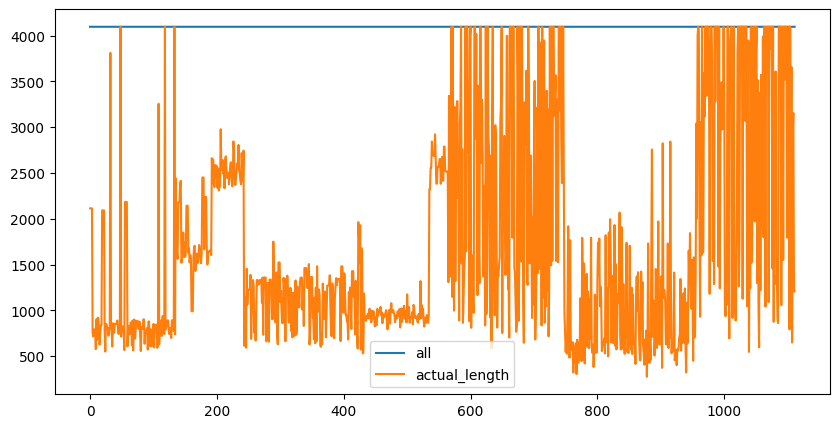

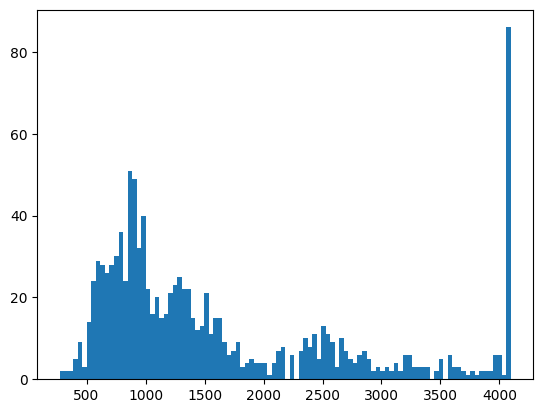

In [21]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))

plt.plot(counts)
plt.plot(counts_positives)
plt.legend(["all", "actual_length"])
plt.show()

plt.hist(counts_positives, bins=100)
plt.show()

In [39]:
pred_idx = torch.argmax(logits, dim=-1)
pred_idx.shape

torch.Size([2, 50])

In [34]:
print("logits view: ", logits.view(-1, logits.shape[-1]).shape)
print("labels view: ",labels.view(-1).shape)

logits view:  torch.Size([80, 4])
labels view:  torch.Size([80])


In [36]:
labels.shape

torch.Size([2, 40])